# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Import Data

In [2]:
column_name = ['unit_number', 'time_cycles'] + [f'op_sett_{i}' for i in range(1,4)] + [f'sensor_{i}' for i in range(1,22)]

df_train = pd.read_csv('train_FD002.txt', sep='\s+', header=None, names=column_name)
df_test = pd.read_csv('test_FD002.txt', sep='\s+', header=None, names=column_name)
df_RUL = pd.read_csv('RUL_FD002.txt', sep='\s+', header=None, names=['RUL'])


In [3]:
df_train

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,20.0037,0.7000,100.0,491.19,608.79,1495.60,1269.51,9.35,...,314.05,2389.02,8169.64,9.3035,0.03,369,2324,100.00,24.36,14.5189
53755,260,313,10.0022,0.2510,100.0,489.05,605.81,1514.32,1324.12,10.52,...,371.22,2388.42,8245.36,8.7586,0.03,374,2319,100.00,28.10,16.9454
53756,260,314,25.0041,0.6200,60.0,462.54,537.48,1276.24,1057.92,7.05,...,163.74,2030.33,7971.25,11.0657,0.02,310,1915,84.93,14.19,8.5503
53757,260,315,25.0033,0.6220,60.0,462.54,537.84,1272.95,1066.30,7.05,...,164.37,2030.35,7972.47,11.0537,0.02,311,1915,84.93,14.05,8.3729


In [4]:
df_test

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,9.9987,0.2502,100.0,489.05,605.03,1497.17,1304.99,10.52,...,371.69,2388.18,8114.10,8.6476,0.03,369,2319,100.00,28.42,17.1551
1,1,2,20.0026,0.7000,100.0,491.19,607.82,1481.20,1246.11,9.35,...,315.32,2388.12,8053.06,9.2405,0.02,364,2324,100.00,24.29,14.8039
2,1,3,35.0045,0.8400,100.0,449.44,556.00,1359.08,1128.36,5.48,...,183.04,2387.75,8053.04,9.3472,0.02,333,2223,100.00,14.98,8.9125
3,1,4,42.0066,0.8410,100.0,445.00,550.17,1349.69,1127.89,3.91,...,130.40,2387.72,8066.90,9.3961,0.02,332,2212,100.00,10.35,6.4181
4,1,5,24.9985,0.6213,60.0,462.54,536.72,1253.18,1050.69,7.05,...,164.56,2028.05,7865.66,10.8682,0.02,305,1915,84.93,14.31,8.5740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33986,259,119,35.0015,0.8403,100.0,449.44,555.56,1366.01,1129.47,5.48,...,183.05,2388.39,8088.36,9.3215,0.02,334,2223,100.00,14.94,8.9065
33987,259,120,42.0066,0.8405,100.0,445.00,549.42,1351.13,1123.86,3.91,...,130.74,2388.31,8108.48,9.3542,0.02,332,2212,100.00,10.57,6.4075
33988,259,121,42.0061,0.8400,100.0,445.00,549.65,1349.14,1118.91,3.91,...,130.96,2388.34,8098.77,9.3836,0.02,331,2212,100.00,10.57,6.4805
33989,259,122,0.0024,0.0003,100.0,518.67,642.58,1589.61,1408.16,14.62,...,522.25,2388.00,8161.85,8.4279,0.03,393,2388,100.00,39.08,23.3589


In [5]:
df_RUL

,RUL
0,18
1,79
2,106
3,110
4,15
...,...
254,122
255,191
256,56
257,131


# Initial Data Analysis

In [6]:
print(f'Number of train samples: {df_train.shape[0]}')
print(f'Number of train columns: {df_train.shape[1]}\n')

print(f'Number of test samples: {df_test.shape[0]}')
print(f'Number of test columns: {df_test.shape[1]}')

Number of train samples: 53759
Number of train columns: 26

Number of test samples: 33991
Number of test columns: 26


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53759 entries, 0 to 53758
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  53759 non-null  int64  
 1   time_cycles  53759 non-null  int64  
 2   op_sett_1    53759 non-null  float64
 3   op_sett_2    53759 non-null  float64
 4   op_sett_3    53759 non-null  float64
 5   sensor_1     53759 non-null  float64
 6   sensor_2     53759 non-null  float64
 7   sensor_3     53759 non-null  float64
 8   sensor_4     53759 non-null  float64
 9   sensor_5     53759 non-null  float64
 10  sensor_6     53759 non-null  float64
 11  sensor_7     53759 non-null  float64
 12  sensor_8     53759 non-null  float64
 13  sensor_9     53759 non-null  float64
 14  sensor_10    53759 non-null  float64
 15  sensor_11    53759 non-null  float64
 16  sensor_12    53759 non-null  float64
 17  sensor_13    53759 non-null  float64
 18  sensor_14    53759 non-null  float64
 19  sens

In [8]:
df_train.iloc[:,2:].describe().iloc[:,:15]

,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,23.998407,0.572056,94.046020,472.910207,579.672399,1419.971013,1205.442024,8.031986,11.600746,282.606787,2228.879188,8525.200837,1.094962,42.985172,266.069034
std,14.747376,0.310016,14.237735,26.389707,37.289399,105.946341,119.123428,3.613839,5.431802,146.005306,145.209816,335.812013,0.127469,3.232372,137.659507
min,0.000000,0.000000,60.000000,445.000000,535.530000,1243.730000,1023.770000,3.910000,5.710000,136.800000,1914.770000,7985.560000,0.930000,36.230000,129.120000
25%,10.004600,0.250700,100.000000,445.000000,549.570000,1352.760000,1123.655000,3.910000,5.720000,139.935000,2211.880000,8321.660000,1.020000,41.910000,131.520000
50%,25.001300,0.700000,100.000000,462.540000,555.980000,1369.180000,1138.890000,7.050000,9.030000,194.660000,2223.070000,8361.200000,1.020000,42.390000,183.200000
75%,41.998000,0.840000,100.000000,491.190000,607.340000,1499.370000,1306.850000,10.520000,15.490000,394.080000,2323.960000,8778.030000,1.260000,45.350000,371.260000
max,42.008000,0.842000,100.000000,518.670000,644.520000,1612.880000,1439.230000,14.620000,21.610000,555.820000,2388.390000,9215.660000,1.300000,48.510000,523.370000


In [9]:
df_train.iloc[:,2:].describe().iloc[:,15:]

,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,2334.557253,8066.597682,9.329654,0.023326,348.309511,2228.806358,97.756838,20.789296,12.473423
std,128.068271,84.837950,0.749335,0.004711,27.754515,145.327980,5.364067,9.869331,5.921615
min,2027.610000,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.180000,6.010500
25%,2387.900000,8062.140000,8.677800,0.020000,331.000000,2212.000000,100.000000,10.910000,6.546300
50%,2388.080000,8082.540000,9.310900,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929200
75%,2388.170000,8127.195000,9.386900,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083200
max,2390.480000,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.340000,23.590100


## Checking Nan Values

In [10]:
df_train.isnull().sum()

unit_number    0
time_cycles    0
op_sett_1      0
op_sett_2      0
op_sett_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
dtype: int64

## Checking Variance for each Column

In [11]:
Variance = np.std(df_train, axis=0).sort_values()
Variance

sensor_16        0.004711
sensor_10        0.127468
op_sett_2        0.310013
sensor_15        0.749329
sensor_11        3.232342
sensor_5         3.613805
sensor_19        5.364017
sensor_6         5.431751
sensor_21        5.921560
sensor_20        9.869239
op_sett_3       14.237602
op_sett_1       14.747239
sensor_1        26.389462
sensor_17       27.754257
sensor_2        37.289052
time_cycles     69.179925
unit_number     74.463169
sensor_14       84.837161
sensor_3       105.945355
sensor_4       119.122320
sensor_13      128.067080
sensor_12      137.658227
sensor_8       145.208465
sensor_18      145.326628
sensor_7       146.003948
sensor_9       335.808889
dtype: float64

In [12]:
print(f'Eliminated features with the lowest variance: {Variance[Variance.values < 0.001].index.to_list()}')

Eliminated features with the lowest variance: []


In [13]:
#df_train.drop(columns=Variance[Variance.values < 0.001].index.to_list(),inplace=True)
#df_test.drop(columns=Variance[Variance.values < 0.001].index.to_list(),inplace=True)

print('After the elimination of features with Zero/Near-Zero variance\n')

print(f'Number of train samples: {df_train.shape[0]}')
print(f'Number of train columns: {df_train.shape[1]}\n')

print(f'Number of test samples: {df_test.shape[0]}')
print(f'Number of test columns: {df_test.shape[1]}')

After the elimination of features with Zero/Near-Zero variance

Number of train samples: 53759
Number of train columns: 26

Number of test samples: 33991
Number of test columns: 26


# Degradation Patterns Analysis

In [14]:
# Choose 2 unique engines to show their features across time

engine_id = df_train['unit_number'].unique()
selected_id_engine = np.random.choice(engine_id, size=2, replace=False)

print(f'Selected Id Engines: {selected_id_engine}')
print(f'number of train columns: {df_train.shape[1]}')
print(f'name of train columns: {df_train.columns.to_list()}')


Selected Id Engines: [ 60 146]
number of train columns: 26
name of train columns: ['unit_number', 'time_cycles', 'op_sett_1', 'op_sett_2', 'op_sett_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


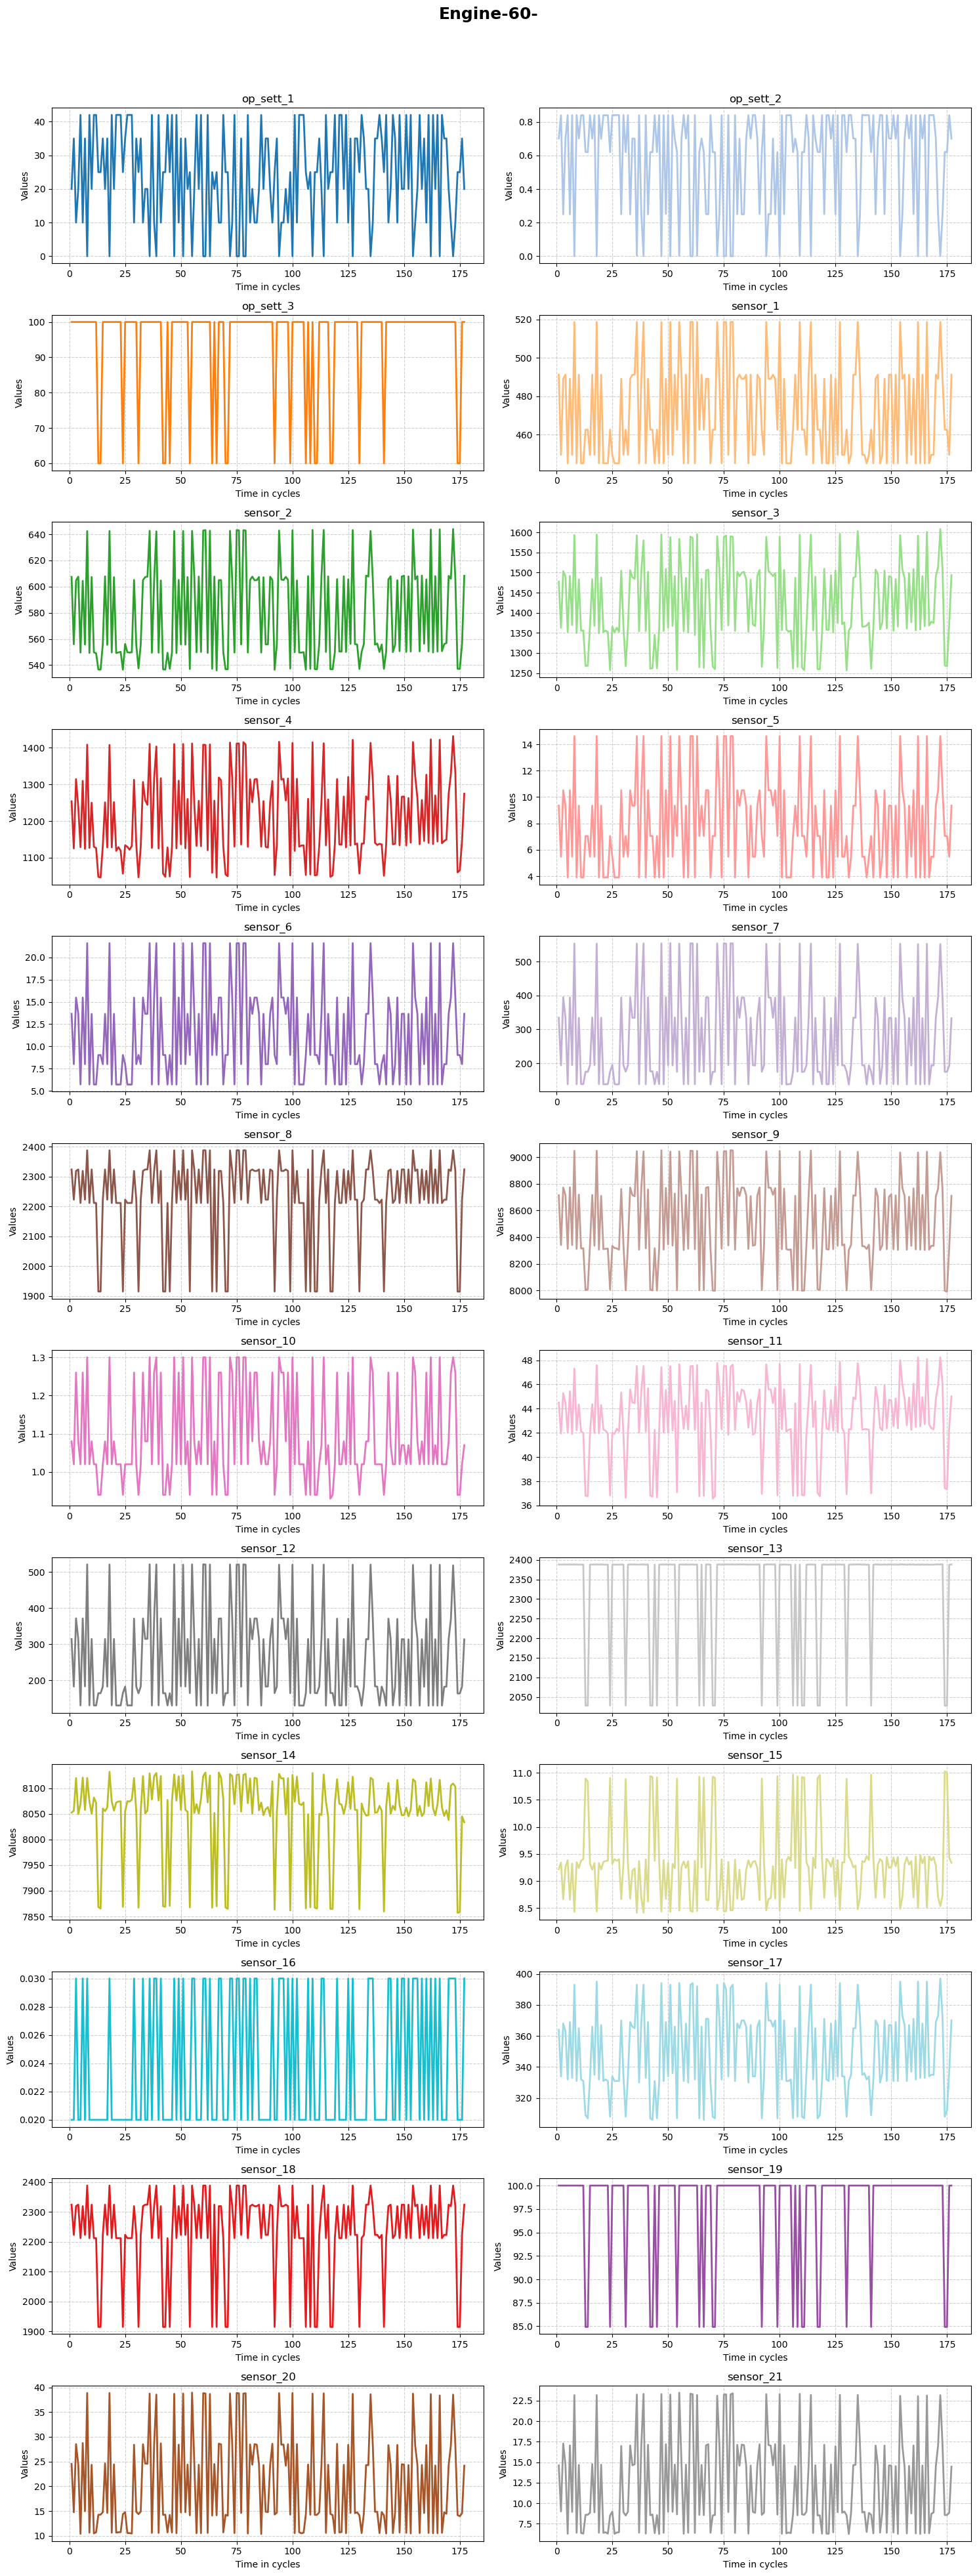

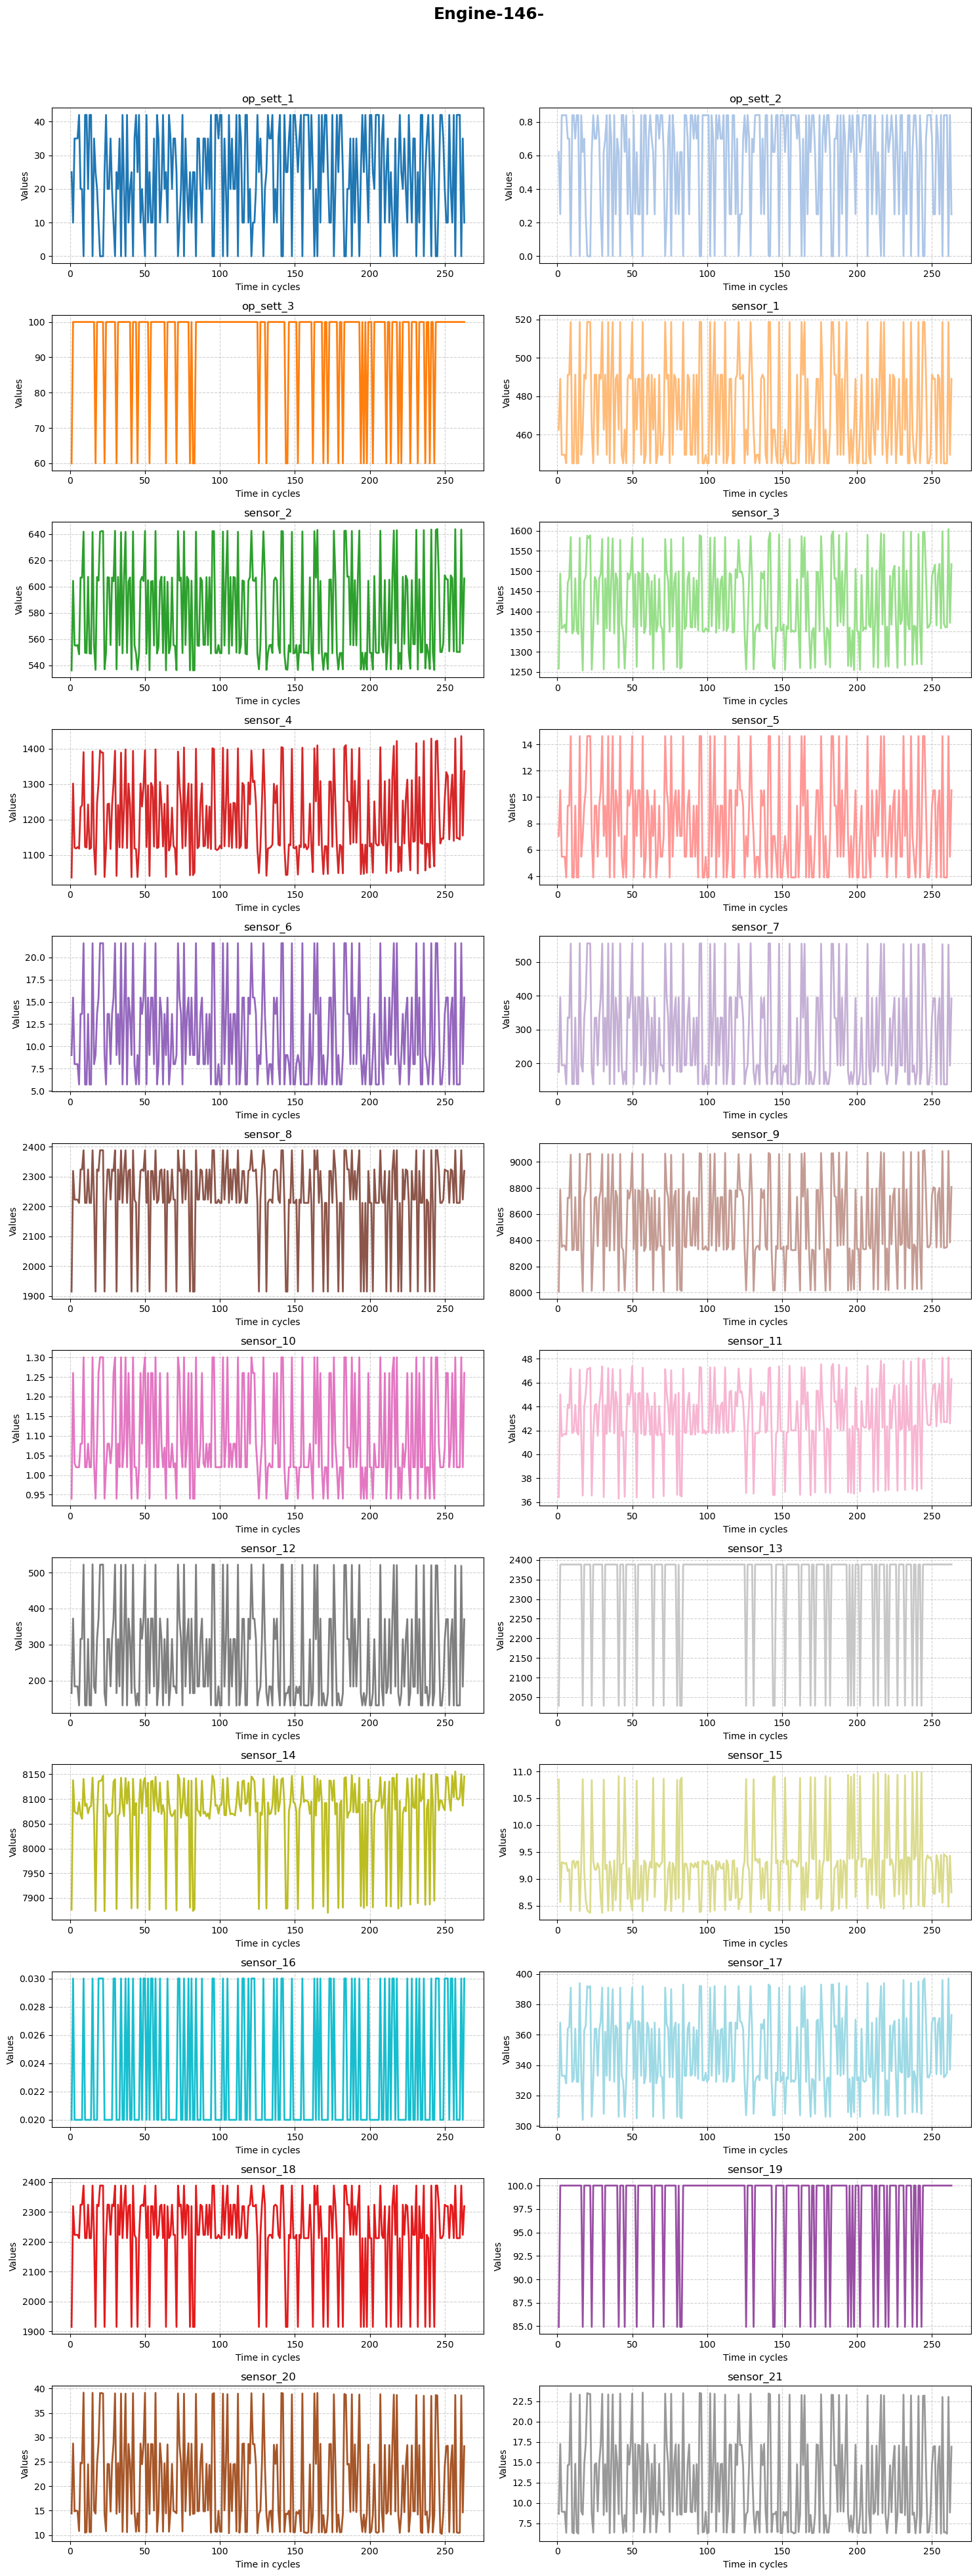

In [15]:
import matplotlib.colors as mcolors
import matplotlib as mpl

# Colors
tab20_cmap = mpl.colormaps['tab20']
set1_cmap = mpl.colormaps['Set1']
tab20_colors = tab20_cmap.resampled(20).colors
set1_colors = set1_cmap.resampled(4).colors
# Convert the RGB to hex 
tab20_hex = [mcolors.to_hex(c) for c in tab20_colors]
set1_hex = [mcolors.to_hex(c) for c in set1_colors]

plot_colors = tab20_hex + set1_hex


for id in selected_id_engine:
    selected_engine_samples = df_train[df_train['unit_number'].isin([id])]

    fig, axes = plt.subplots(12,2, figsize = (15,40))
    fig.suptitle(f'Engine-{int(id)}-', fontsize = 18, weight='bold')

    all_axes = axes.flatten()
    for ax in range(df_train.shape[1]-2):
        current_ax = all_axes[ax]
        columns_number = ax+2
        current_ax.plot(selected_engine_samples['time_cycles'], selected_engine_samples.iloc[0:,columns_number],
                        color= plot_colors[ax], linewidth = 2)
        
        current_ax.grid(True, linestyle = '--', alpha=0.6)
        current_ax.set_title(f'{df_train.columns.to_list()[columns_number]}', fontsize=12)
        current_ax.set_xlabel('Time in cycles')
        current_ax.set_ylabel('Values')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
    #all_axes[-1].axis('off')
plt.show()        


# Feature Engineering

In [16]:
total_lifetime = df_train.groupby(['unit_number']).time_cycles.max().reset_index()
total_lifetime.columns = ['unit_number','max_cycles']
total_lifetime


,unit_number,max_cycles
0,1,149
1,2,269
2,3,206
3,4,235
4,5,154
...,...,...
255,256,163
256,257,309
257,258,143
258,259,205


In [17]:
df_train = df_train.merge(total_lifetime, on='unit_number', how='left')
df_train

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,149
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,149
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,149
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,149
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,20.0037,0.7000,100.0,491.19,608.79,1495.60,1269.51,9.35,...,2389.02,8169.64,9.3035,0.03,369,2324,100.00,24.36,14.5189,316
53755,260,313,10.0022,0.2510,100.0,489.05,605.81,1514.32,1324.12,10.52,...,2388.42,8245.36,8.7586,0.03,374,2319,100.00,28.10,16.9454,316
53756,260,314,25.0041,0.6200,60.0,462.54,537.48,1276.24,1057.92,7.05,...,2030.33,7971.25,11.0657,0.02,310,1915,84.93,14.19,8.5503,316
53757,260,315,25.0033,0.6220,60.0,462.54,537.84,1272.95,1066.30,7.05,...,2030.35,7972.47,11.0537,0.02,311,1915,84.93,14.05,8.3729,316


In [18]:
df_train['RUL'] = df_train['max_cycles'] - df_train['time_cycles']
df_train

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,149,148
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,149,147
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,149,146
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,149,145
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,149,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,20.0037,0.7000,100.0,491.19,608.79,1495.60,1269.51,9.35,...,8169.64,9.3035,0.03,369,2324,100.00,24.36,14.5189,316,4
53755,260,313,10.0022,0.2510,100.0,489.05,605.81,1514.32,1324.12,10.52,...,8245.36,8.7586,0.03,374,2319,100.00,28.10,16.9454,316,3
53756,260,314,25.0041,0.6200,60.0,462.54,537.48,1276.24,1057.92,7.05,...,7971.25,11.0657,0.02,310,1915,84.93,14.19,8.5503,316,2
53757,260,315,25.0033,0.6220,60.0,462.54,537.84,1272.95,1066.30,7.05,...,7972.47,11.0537,0.02,311,1915,84.93,14.05,8.3729,316,1


### piece-wise RUL

In [19]:
df_train['RUL'] = df_train['RUL'].clip(upper = 130)
df_train['RUL']

0        130
1        130
2        130
3        130
4        130
        ... 
53754      4
53755      3
53756      2
53757      1
53758      0
Name: RUL, Length: 53759, dtype: int64

In [20]:
df_RUL = df_RUL.clip(upper=130)
df_RUL

,RUL
0,18
1,79
2,106
3,110
4,15
...,...
254,122
255,130
256,56
257,130


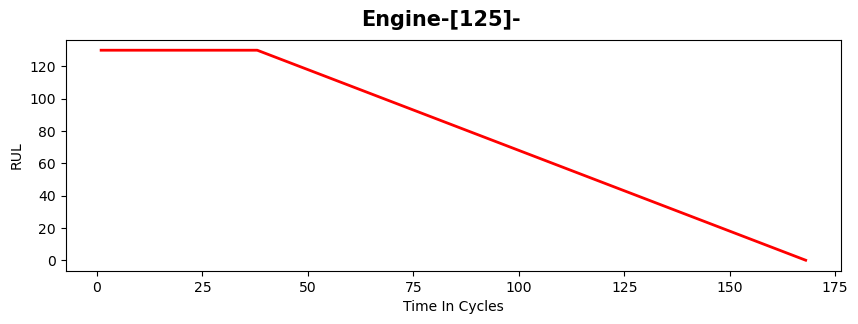

Maximum Lifetime of Engine-[125]-: 168


In [21]:
# Plot RUL - time_in_cycles for one random engine

ID_Engine = np.random.choice(df_train['unit_number'].unique(),size=1)

fig = plt.figure(figsize = (10,3))

fig.suptitle(f'Engine-{ID_Engine}-', fontsize=15, weight='bold')
engine_samples = df_train[df_train['unit_number'].isin(ID_Engine)]

plt.plot(engine_samples['time_cycles'],engine_samples['RUL'], linewidth=2, color='red')

plt.xlabel('Time In Cycles')
plt.ylabel('RUL')
plt.show()

print('Maximum Lifetime of Engine-{}-: {}'.format(ID_Engine,engine_samples.iloc[0,engine_samples.columns.get_loc('max_cycles')]))

In [22]:
df_train.drop('max_cycles',axis=1,inplace=True)
df_train

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,130
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,130
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,130
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,130
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,20.0037,0.7000,100.0,491.19,608.79,1495.60,1269.51,9.35,...,2389.02,8169.64,9.3035,0.03,369,2324,100.00,24.36,14.5189,4
53755,260,313,10.0022,0.2510,100.0,489.05,605.81,1514.32,1324.12,10.52,...,2388.42,8245.36,8.7586,0.03,374,2319,100.00,28.10,16.9454,3
53756,260,314,25.0041,0.6200,60.0,462.54,537.48,1276.24,1057.92,7.05,...,2030.33,7971.25,11.0657,0.02,310,1915,84.93,14.19,8.5503,2
53757,260,315,25.0033,0.6220,60.0,462.54,537.84,1272.95,1066.30,7.05,...,2030.35,7972.47,11.0537,0.02,311,1915,84.93,14.05,8.3729,1


# Normalizing

In [23]:
X_train = df_train.drop('RUL',axis=1)
X_test = df_test
y_train = df_train['RUL']
y_test = df_RUL

In [24]:
stdscaler_X = StandardScaler()
stdscaler_Y = StandardScaler()

In [ ]:
X_train_norm = pd.merge(X_train.iloc[:,0:2], pd.DataFrame(stdscaler_X.fit_transform(X_train.iloc[:,2:]), index=X_train.index, 
                                                          columns=X_train.iloc[:,2:].columns),left_index=True, right_index=True, how='inner')
X_test_norm = pd.merge(X_test.iloc[:,0:2], pd.DataFrame(stdscaler_X.transform(X_test.iloc[:,2:]), index=X_test.index,
                                                         columns=X_test.iloc[:,2:].columns),left_index=True, right_index=True, how='inner')

y_train_norm = pd.Series(stdscaler_Y.fit_transform(y_train.values.reshape(-1,1)).flatten(), index=y_train.index)
y_test_norm = pd.Series(stdscaler_Y.transform(y_test.values.reshape(-1,1)).flatten(), index=y_test.index)

In [26]:
X_train_norm.describe()

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,53759.000000,53759.000000,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,...,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04,5.375900e+04
mean,131.082981,109.154746,-3.047883e-16,-3.859418e-17,5.606731e-16,-4.551999e-16,-1.593993e-16,1.048916e-15,9.207092e-16,-2.260139e-17,...,2.479544e-16,-1.369565e-15,1.994209e-15,9.780718e-17,-1.316167e-15,7.291922e-16,1.710304e-16,-2.262782e-16,2.603786e-17,7.613099e-17
std,74.463862,69.180569,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,...,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00
min,1.000000,1.000000,-1.627315e+00,-1.845265e+00,-2.391275e+00,-1.057627e+00,-1.183790e+00,-1.663509e+00,-1.525088e+00,-1.140622e+00,...,-9.948482e-01,-2.396769e+00,-2.572430e+00,-1.326459e+00,-7.059332e-01,-1.632525e+00,-2.159318e+00,-2.391275e+00,-1.074986e+00,-1.091422e+00
25%,68.000000,52.000000,-9.489103e-01,-1.036590e+00,4.181870e-01,-1.057627e+00,-8.072718e-01,-6.343932e-01,-6.865802e-01,-1.140622e+00,...,-9.774137e-01,4.165219e-01,-5.254398e-02,-8.699169e-01,-7.059332e-01,-6.236705e-01,-1.156454e-01,4.181870e-01,-1.001019e+00,-1.000939e+00
50%,131.000000,104.000000,6.800545e-02,4.127040e-01,4.181870e-01,-3.929677e-01,-6.353715e-01,-4.794076e-01,-5.586864e-01,-2.717319e-01,...,-6.019912e-01,4.179274e-01,1.879167e-01,-2.502713e-02,-7.059332e-01,-4.795484e-01,-3.995385e-02,4.181870e-01,-5.987590e-01,-5.985285e-01
75%,195.000000,157.000000,1.220540e+00,8.642978e-01,4.181870e-01,6.926929e-01,7.419765e-01,7.494334e-01,8.512928e-01,6.884748e-01,...,7.641459e-01,4.186302e-01,7.142780e-01,7.639701e-02,1.416565e+00,7.454888e-01,6.550323e-01,4.181870e-01,7.782468e-01,7.784734e-01
max,260.000000,378.000000,1.221218e+00,8.707492e-01,4.181870e-01,1.734018e+00,1.739052e+00,1.820835e+00,1.962588e+00,1.823013e+00,...,1.869129e+00,4.366676e-01,2.379881e+00,2.318404e+00,1.416565e+00,1.826404e+00,1.095420e+00,4.181870e-01,1.879649e+00,1.877322e+00


In [27]:
X_test_norm.describe()

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,...,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000,33991.000000
mean,127.528346,81.223647,-0.001575,-0.002911,0.001450,0.000752,-0.002164,-0.013299,-0.019774,0.001945,...,0.003126,0.001089,-0.034877,-0.019269,-0.039230,-0.013357,0.001507,0.001450,0.005043,0.005150
std,74.144727,58.892845,1.002151,1.003176,0.998582,1.002472,1.001338,1.000319,0.999304,1.002774,...,1.003244,0.998605,0.988117,0.997706,0.985196,1.000188,0.999374,0.998582,1.004007,1.003888
min,1.000000,1.000000,-1.627315,-1.845265,-2.391275,-1.057627,-1.187008,-1.650011,-1.472033,-1.140622,...,-0.993468,-2.395364,-2.537658,-1.333799,-0.705933,-1.632525,-2.159318,-2.391275,-1.074986,-1.072407
25%,65.000000,34.000000,-0.948910,-1.036912,0.418187,-0.889378,-0.809685,-0.644965,-0.696108,-0.706177,...,-0.743101,0.416444,-0.061561,-0.889001,-0.705933,-0.659701,-0.115645,0.418187,-0.688938,-0.686689
50%,128.000000,70.000000,0.068005,0.412704,0.418187,-0.392968,-0.639394,-0.496492,-0.598394,-0.271732,...,-0.601555,0.417771,0.161277,-0.034903,-0.705933,-0.515579,-0.039954,0.418187,-0.596733,-0.596907
75%,189.000000,119.000000,0.746553,0.864298,0.418187,0.692693,0.739831,0.739334,0.839582,0.688475,...,0.765526,0.418318,0.698306,0.059849,1.416565,0.745489,0.655032,0.418187,0.783313,0.783202
max,259.000000,367.000000,1.221218,0.870749,0.418187,1.734018,1.733688,1.790725,1.919690,1.823013,...,1.868039,0.432607,2.080484,2.269160,1.416565,1.790374,1.095420,0.418187,1.877622,1.881375


In [28]:
y_train_norm.describe()

count    5.375900e+04
mean    -6.767200e-17
std      1.000009e+00
min     -2.044698e+00
25%     -8.706180e-01
50%      3.264833e-01
75%      9.480551e-01
max      9.480551e-01
dtype: float64

In [29]:
y_test_norm.describe()

count    259.000000
mean      -0.323621
std        1.020566
min       -1.906571
25%       -1.238957
50%       -0.203004
75%        0.740865
max        0.948055
dtype: float64

# Feature Selection

In [30]:
print(f'Number Of Train Samples : {X_train.shape[0]}')
print(f'Number Of Train Features : {len(X_train.columns[2:])}\n')

print(f'Number Of Test Samples : {X_test.shape[0]}')
print(f'Number Of Test Features : {len(X_test.columns[2:])}\n')

print(f'Number Of Train Targets : {y_train.shape[0]}')
print(f'Number Of Test Targets : {y_test.shape[0]}\n')


Number Of Train Samples : 53759
Number Of Train Features : 24

Number Of Test Samples : 33991
Number Of Test Features : 24

Number Of Train Targets : 53759
Number Of Test Targets : 259



## Correlation

<Axes: >

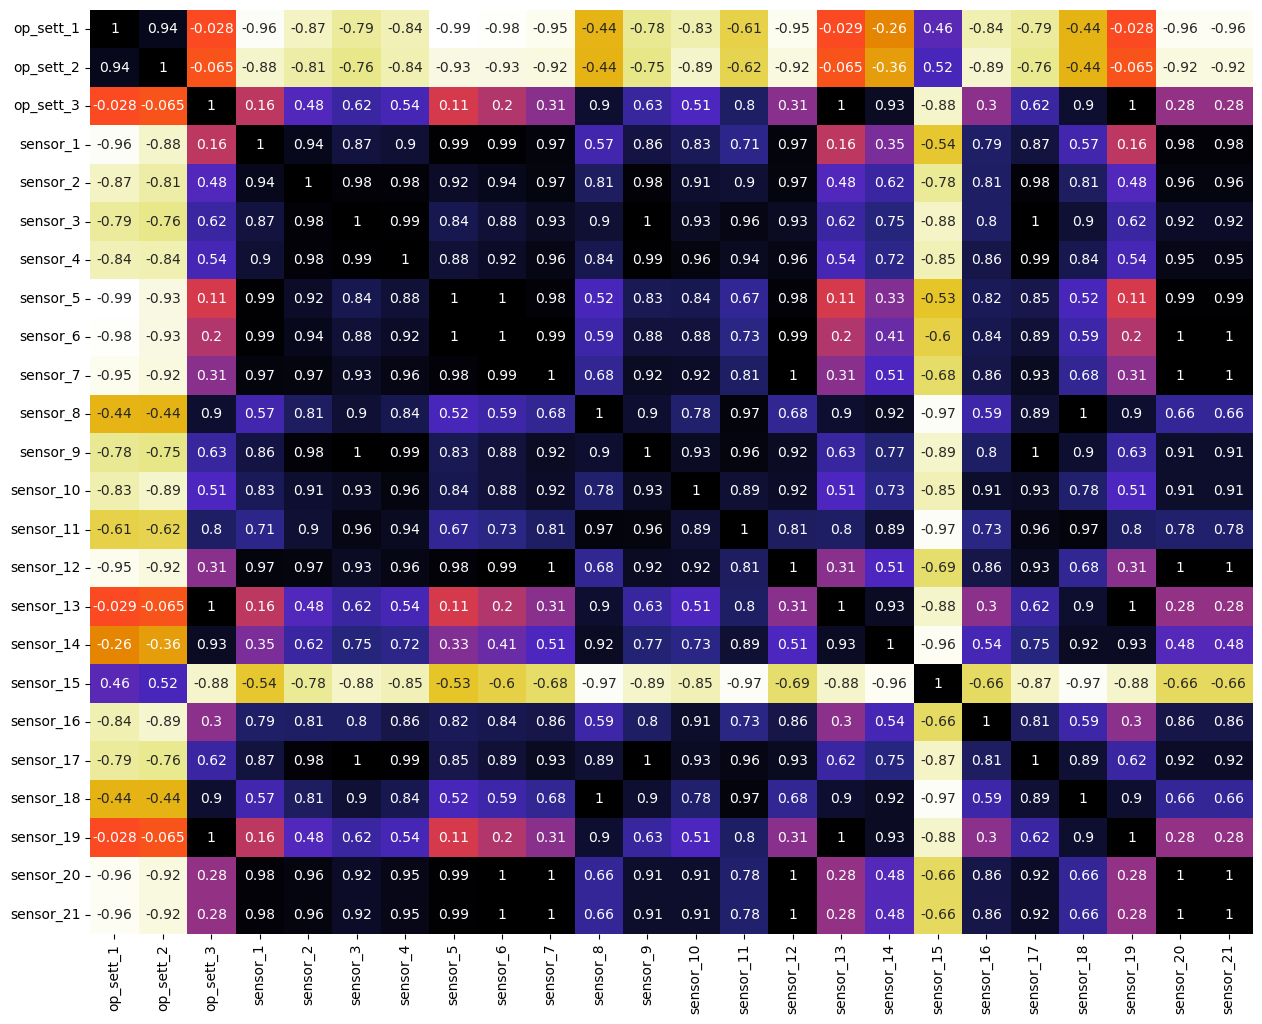

In [31]:
corr_matrix = X_train.iloc[:,2:].corr()

plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix,annot=True,cmap=plt.cm.CMRmap_r,cbar=False)

In [32]:
def correlation(Dataset,Threshold):
    corrMatrix = Dataset.corr()
    num_features = len(Dataset.columns)
    corr = set()
    for i in range(num_features):
        for j in range(i):
            if abs(corrMatrix.iloc[i,j]) > Threshold :
                first_column_name = corrMatrix.columns[i]
                second_column_name = corrMatrix.columns[j]
                corr.add((first_column_name,second_column_name))
    
    return corr
Corr_Thre = 0.9
features_high_correlation = correlation(X_train.iloc[:,2:],Corr_Thre)
print(f'Features With Higher Corralation than {Corr_Thre} : {features_high_correlation}')

Features With Higher Corralation than 0.9 : {('sensor_4', 'sensor_2'), ('sensor_10', 'sensor_4'), ('sensor_21', 'sensor_3'), ('sensor_20', 'sensor_3'), ('sensor_9', 'sensor_2'), ('sensor_17', 'sensor_4'), ('sensor_18', 'sensor_11'), ('sensor_7', 'op_sett_1'), ('sensor_21', 'sensor_10'), ('sensor_5', 'sensor_1'), ('sensor_20', 'sensor_10'), ('sensor_12', 'op_sett_1'), ('sensor_6', 'op_sett_1'), ('sensor_21', 'sensor_20'), ('sensor_18', 'sensor_13'), ('sensor_7', 'sensor_6'), ('sensor_14', 'sensor_13'), ('sensor_20', 'sensor_9'), ('sensor_21', 'sensor_9'), ('sensor_12', 'sensor_2'), ('sensor_21', 'sensor_17'), ('sensor_20', 'sensor_17'), ('sensor_12', 'sensor_6'), ('sensor_6', 'sensor_2'), ('sensor_19', 'sensor_18'), ('sensor_21', 'sensor_7'), ('sensor_19', 'op_sett_3'), ('sensor_20', 'sensor_7'), ('sensor_20', 'sensor_5'), ('sensor_14', 'op_sett_3'), ('sensor_21', 'sensor_5'), ('sensor_19', 'sensor_14'), ('sensor_13', 'sensor_8'), ('sensor_7', 'sensor_4'), ('sensor_12', 'sensor_4'), ('s

<Axes: >

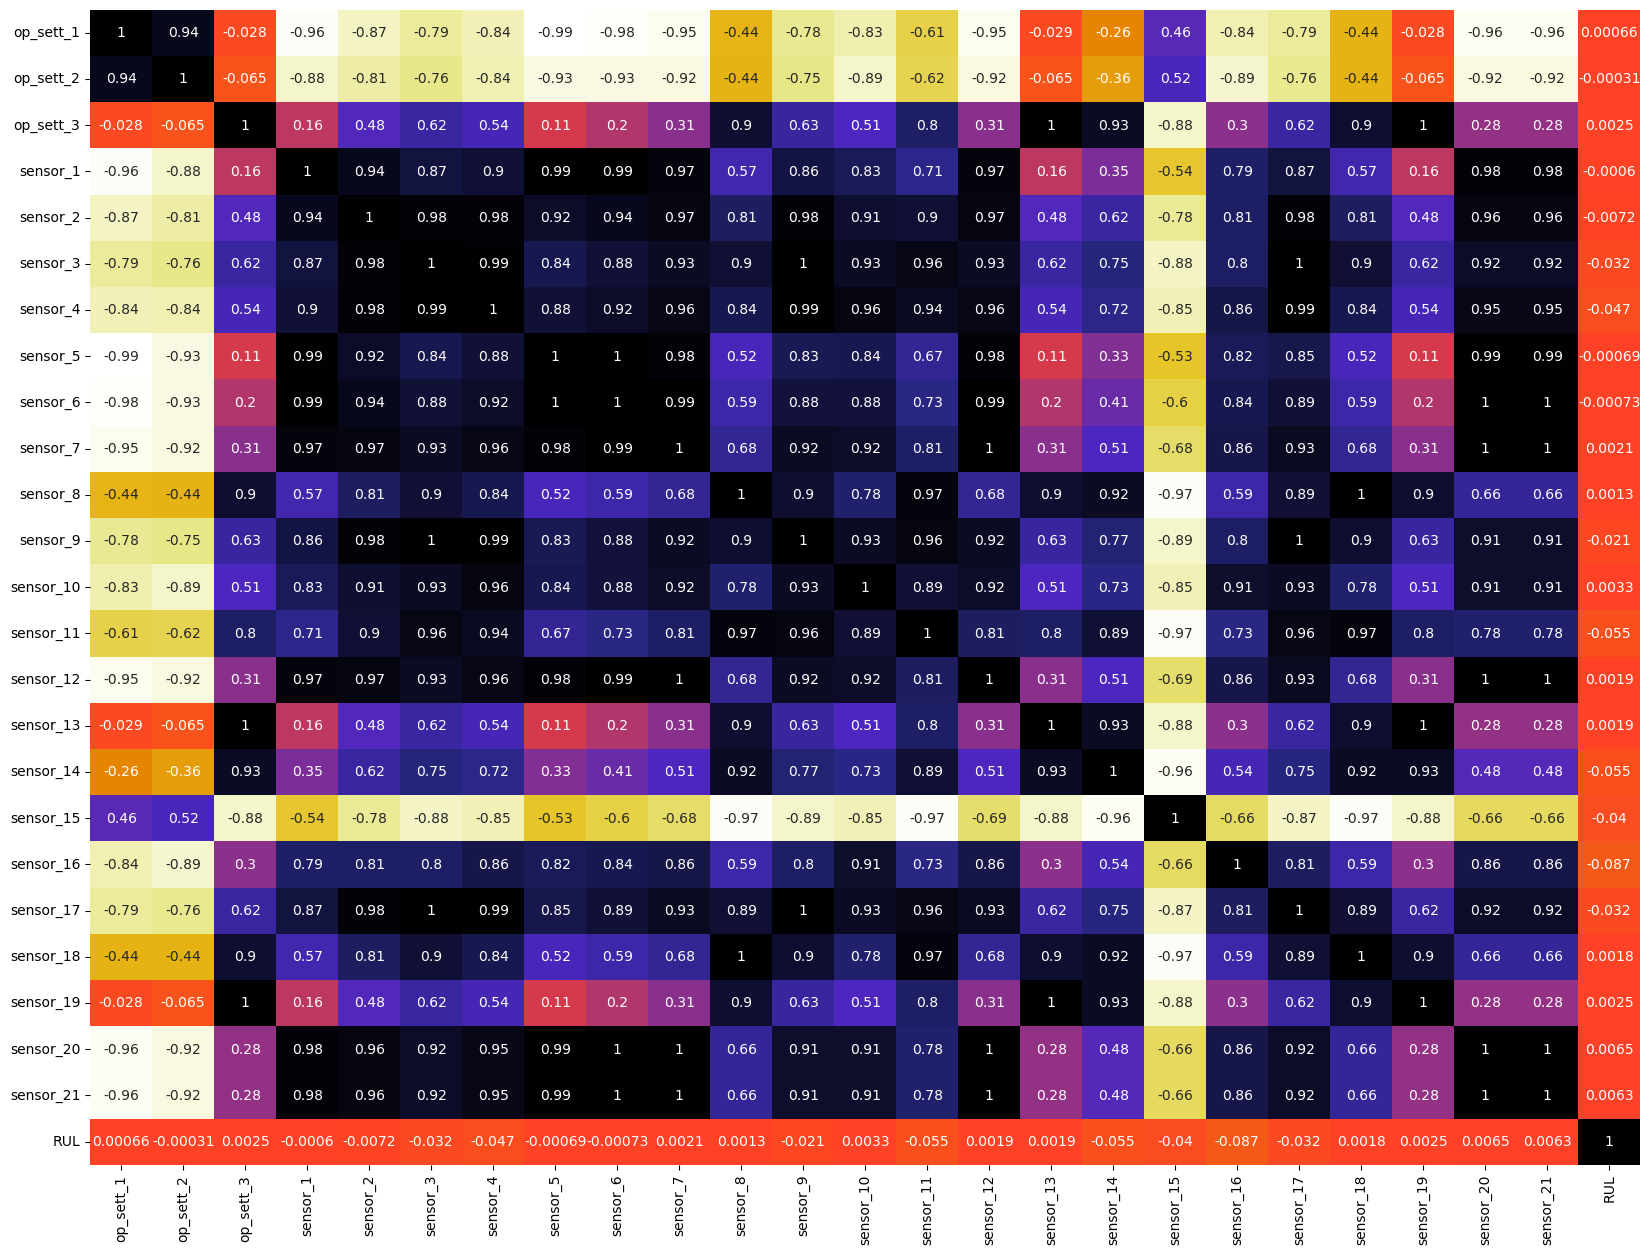

In [33]:
# The Correlation Between Features are high so we calculate corraltion between features and Target(RUL) to select appropriate features
corr_matrix = df_train.iloc[:,2:].corr()

plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix,annot=True,cmap=plt.cm.CMRmap_r,cbar=False)

In [34]:
def correlation_Target(Dataset,Threshold,target):
    corrMatrix = Dataset.corr()
    target_column = Dataset.columns.get_loc(target)
    num_features = len(Dataset.columns)
    corr = set()
    for i in range(num_features):
        if i not in [target_column]:
            if abs(corrMatrix.iloc[target_column,i]) > Threshold :
                column_name = corrMatrix.columns[i]
                corr.add((column_name,corrMatrix.iloc[target_column,i]))
    
    return corr
Corr_Thre = 0.01
features_high_correlation = correlation_Target(df_train.iloc[:,2:],Corr_Thre,'RUL')
print(f'Features With Higher Corralation than {Corr_Thre} to RUL : {features_high_correlation}')
print(f'Selected Features with correlation method : {[x[0] for x in features_high_correlation]}')
print(f'Number of selected features with correlation method : {len(features_high_correlation)}')

Features With Higher Corralation than 0.01 to RUL : {('sensor_14', -0.05547346491461397), ('sensor_11', -0.05502283356918138), ('sensor_16', -0.08684073332193601), ('sensor_17', -0.03244819653230028), ('sensor_9', -0.020715993641093517), ('sensor_3', -0.03217947131189837), ('sensor_15', -0.03960467239984327), ('sensor_4', -0.04742016635542879)}
Selected Features with correlation method : ['sensor_14', 'sensor_11', 'sensor_16', 'sensor_17', 'sensor_9', 'sensor_3', 'sensor_15', 'sensor_4']
Number of selected features with correlation method : 8


## Mutual Information

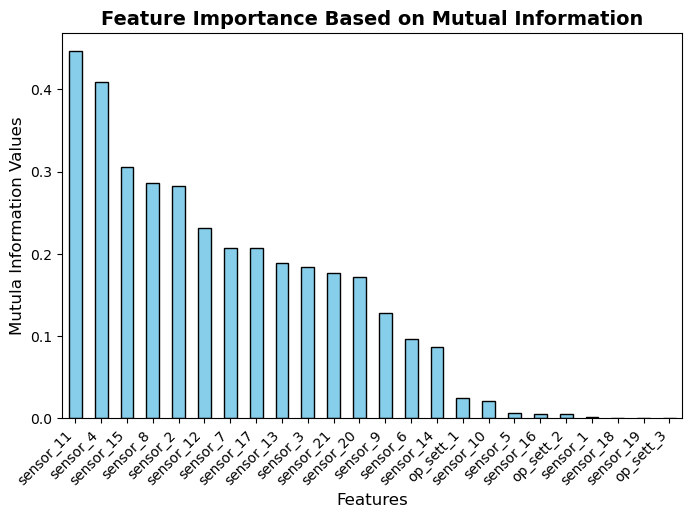

In [35]:
mutual_info_values = mutual_info_regression(X_train.iloc[:,2:],y_train,random_state=42)
mutual_info = pd.Series(mutual_info_values, index=X_train.iloc[:,2:].columns)
plot = mutual_info.sort_values(ascending=False).plot.bar(figsize=(8,5), color='skyblue', edgecolor='black')
plt.title('Feature Importance Based on Mutual Information', fontsize=14, weight='bold')
plt.xlabel('Features', fontsize = 12)
plt.ylabel('Mutula Information Values', fontsize = 12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [36]:
Selected_Features_With_MutualInfo_method = mutual_info[mutual_info.values>0.05]
Selected_Features_With_MutualInfo_method.sort_values(ascending=False)

sensor_11    0.446409
sensor_4     0.409076
sensor_15    0.305003
sensor_8     0.286633
sensor_2     0.282395
sensor_12    0.230972
sensor_7     0.207369
sensor_17    0.206648
sensor_13    0.188310
sensor_3     0.183252
sensor_21    0.176333
sensor_20    0.171303
sensor_9     0.127820
sensor_6     0.096588
sensor_14    0.085926
dtype: float64

## PCA

In [37]:
pca = PCA(n_components=3, svd_solver='covariance_eigh')

In [38]:
X_train_pca = pca.fit_transform(X_train_norm.iloc[:,2:])
X_test_pca = pca.transform(X_test_norm.iloc[:,2:])

In [39]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.77347075, 0.19960673, 0.01907488])

In [40]:
X_train_norm_inverse = pd.DataFrame(pca.inverse_transform(X_train_pca), index=X_train_norm.iloc[:,2:].index, columns=X_train_norm.iloc[:,2:].columns)
X_train_norm_inverse

,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,0.829199,0.845217,0.310202,-0.719950,-0.537353,-0.441874,-0.535115,-0.779771,-0.744377,-0.693874,...,-0.693222,0.310076,0.033754,0.128150,-0.710567,-0.445658,-0.055380,0.310202,-0.709645,-0.709678
1,1.127242,0.970792,0.422177,-1.099739,-0.837350,-0.653805,-0.719873,-1.113054,-1.060031,-0.973450,...,-0.972217,0.422058,0.192711,0.080303,-0.684615,-0.658764,-0.127922,0.422177,-0.999046,-0.999100
2,0.060712,0.173191,-2.409011,-0.387158,-1.148687,-1.493249,-1.316007,-0.263509,-0.467605,-0.731936,...,-0.735230,-2.409084,-2.261458,2.136026,-0.728571,-1.484507,-2.171440,-2.409011,-0.657021,-0.656871
3,1.123906,0.969996,0.411708,-1.096629,-0.838084,-0.656913,-0.722652,-1.110050,-1.058014,-0.972870,...,-0.971657,0.411588,0.182198,0.088997,-0.687765,-0.661826,-0.135269,0.411708,-0.998064,-0.998118
4,0.060560,0.175623,-2.410047,-0.385434,-1.147509,-1.492996,-1.316528,-0.262693,-0.466948,-0.731651,...,-0.734952,-2.410121,-2.264463,2.138193,-0.732723,-1.484252,-2.171546,-2.410047,-0.656644,-0.656493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,-0.315252,-0.300460,0.555744,0.401510,0.542700,0.588215,0.555047,0.369040,0.411432,0.461298,...,0.461876,0.555795,0.571879,-0.610749,0.375962,0.587100,0.636902,0.555744,0.447422,0.447395
53755,-0.775098,-1.236503,0.605460,0.520648,0.667177,0.829506,0.987043,0.684212,0.738305,0.830457,...,0.831866,0.605720,1.135128,-1.115585,1.553160,0.830146,0.729127,0.605460,0.807766,0.807718
53756,0.081122,0.088650,-2.236702,-0.448686,-1.145556,-1.434500,-1.238689,-0.297838,-0.484396,-0.719523,...,-0.722385,-2.236745,-2.026974,1.943853,-0.545896,-1.426359,-2.055153,-2.236702,-0.652421,-0.652288
53757,0.081521,0.086442,-2.225341,-0.448917,-1.141962,-1.428606,-1.232973,-0.297887,-0.483417,-0.717074,...,-0.719916,-2.225384,-2.014795,1.933008,-0.539803,-1.420507,-2.045813,-2.225341,-0.650379,-0.650246


In [41]:
cost_fro = (((np.linalg.norm((X_train_norm.iloc[:,2:] - X_train_norm_inverse), ord='fro'))**2)/((np.linalg.norm(X_train_norm.iloc[:,2:],ord='fro')**2)))
print(f'Reconstruction Frobenius Error: {cost_fro}')

Reconstruction Frobenius Error: 0.00784763943459015


In [42]:
PC_Matrix = pd.DataFrame(pca.components_, index=['PC1','PC2','PC3'] ,columns=X_train_norm.iloc[:,2:].columns)
PC_Matrix

,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
PC1,-0.191857,-0.189880,0.134141,0.205165,0.227346,0.230472,0.231311,0.202397,0.211297,0.220793,...,0.220896,0.134171,0.171485,-0.201805,0.197855,0.230568,0.200843,0.134141,0.218352,0.218347
PC2,0.252839,0.224867,0.372245,-0.195029,-0.049289,0.026035,-0.016548,-0.220196,-0.185254,-0.137230,...,-0.136610,0.372219,0.285341,-0.214318,-0.107622,0.023872,0.224590,0.372245,-0.151193,-0.151221
PC3,-0.006757,-0.385005,-0.028096,-0.255356,-0.235174,-0.125399,0.006540,-0.108720,-0.100825,-0.066013,...,-0.065317,-0.027984,0.287477,-0.177672,0.597229,-0.124877,-0.135275,-0.028096,-0.073899,-0.073919


In [43]:
Selected_features_with_PCA = PC_Matrix.iloc[:,PC_Matrix.iloc[0,:].values > 0.2].columns.to_list()
Selected_features_with_PCA

['sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_17',
 'sensor_18',
 'sensor_20',
 'sensor_21']

## Random Forest Regressor Feature Importance

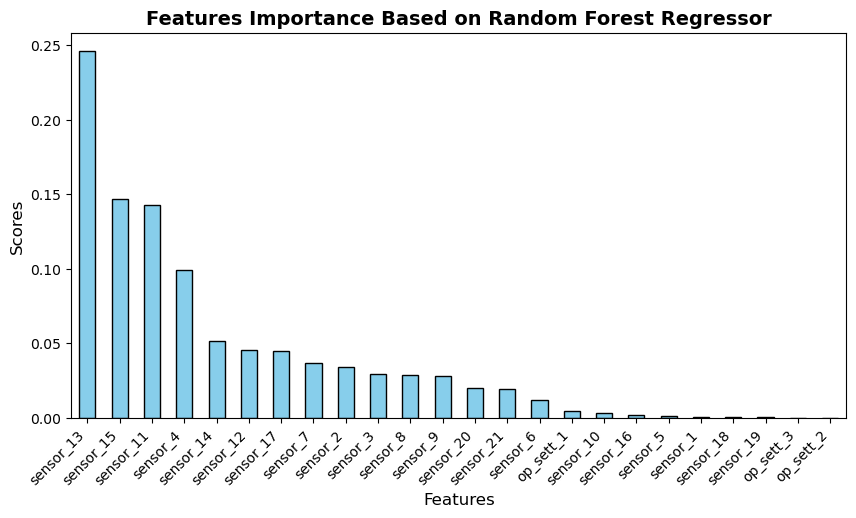

In [44]:
RFR_Features = RandomForestRegressor(n_estimators=200, max_depth=4, max_features=5 ,random_state=42, n_jobs=-1)
RFR_Features.fit(X_train.iloc[:,2:],y_train)
Features_importance_RFR = pd.Series(RFR_Features.feature_importances_, index=X_train.iloc[:,2:].columns)

Features_importance_RFR.sort_values(ascending=False).plot.bar(figsize=(10,5), color='skyblue', edgecolor='black')
plt.title('Features Importance Based on Random Forest Regressor', fontsize=14, weight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [45]:
Selected_Features_With_RFR_method = Features_importance_RFR[Features_importance_RFR.values>0.01]
Selected_Features_With_RFR_method.sort_values(ascending=False)

sensor_13    0.245874
sensor_15    0.147165
sensor_11    0.142706
sensor_4     0.098962
sensor_14    0.051568
sensor_12    0.045662
sensor_17    0.044692
sensor_7     0.037011
sensor_2     0.034506
sensor_3     0.029707
sensor_8     0.029034
sensor_9     0.028298
sensor_20    0.020099
sensor_21    0.019567
sensor_6     0.011824
dtype: float64

# Save Data

In [51]:
print(f'{len([x[0] for x in features_high_correlation])} Selected Features with correlation method : {[x[0] for x in features_high_correlation]}\n')
print(f'{len(Selected_Features_With_MutualInfo_method.index.to_list())} Selected Features with Mutual Information : {Selected_Features_With_MutualInfo_method.index.to_list()}\n')
print(f'{len(Selected_features_with_PCA)} Selected Features with PCA Weight : {Selected_features_with_PCA}\n')
print(f'{len(Selected_Features_With_RFR_method.index.to_list())} Selected Features with Random Forest Regressor : {Selected_Features_With_RFR_method.index.to_list()}\n')

8 Selected Features with correlation method : ['sensor_14', 'sensor_11', 'sensor_16', 'sensor_17', 'sensor_9', 'sensor_3', 'sensor_15', 'sensor_4']

15 Selected Features with Mutual Information : ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

16 Selected Features with PCA Weight : ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_17', 'sensor_18', 'sensor_20', 'sensor_21']

15 Selected Features with Random Forest Regressor : ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']



In [61]:
x_train_PCA_Weight = X_train[Selected_features_with_PCA]
x_test_PCA_Weight = X_test[Selected_features_with_PCA]

x_train_corr = X_train[[x[0] for x in features_high_correlation]]
x_test_corr = X_test[[x[0] for x in features_high_correlation]]

In [62]:
x_train_PCA_Weight.to_csv('x_train_pca_weight_FD2.csv',index=False)
x_test_PCA_Weight.to_csv('x_test_pca_weight_FD2.csv',index=False)

x_train_corr.to_csv('x_train_Corr_FD2.csv',index=False)
x_test_corr.to_csv('x_test_Corr_FD2.csv',index=False)

X_train.to_csv('x_train_FD2.csv',index=False)
X_test.to_csv('x_test_FD2.csv',index=False)

pd.DataFrame(X_train_pca, columns=['PC1','PC2','PC3']).to_csv('x_train_pca_FD2.csv',index=False)
pd.DataFrame(X_test_pca, columns=['PC1','PC2','PC3']).to_csv('x_test_pca_FD2.csv',index=False)

y_train.to_csv('y_train_FD2.csv',index=False)
y_test.to_csv('y_test_FD2.csv',index=False)